In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime

In [122]:
aapl = yf.download("AAPL",start='2020-01-01',end="2026-01-01",auto_adjust=True)
msft = yf.download("MSFT",start='2020-01-01',end="2026-01-01",auto_adjust=True)

print("\n")
print(aapl.head())
print("\n")
print(msft.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400528  72.460791  71.156689  71.409793  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267944  72.306514  70.568518  70.819216  118387200
2020-01-07  71.928055  72.533095  71.708695  72.277578  108872000
2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200


Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2020-01-02  152.158371  152.262577  149.989017  150.415308  22622100
2020-01-03  150.263718  151.523654  149.733221  149.979534  21116200
2020-01-06  150.652176  150.718495  148.264927  148.804906  20813700
2020-01-07  149.278549  151.258443  149.032251  150.92

In [123]:
#Print Rows and Columns of Dataset
print("Apple Dataset",aapl.shape)
print("Microsoft Dataset",msft.shape)

print("Apple Dataset Information")
print(aapl.info())
print("\n")
print("Microsoft Dataset Information")
print(msft.info())

Apple Dataset (1508, 5)
Microsoft Dataset (1508, 5)
Apple Dataset Information
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1508 non-null   float64
 1   (High, AAPL)    1508 non-null   float64
 2   (Low, AAPL)     1508 non-null   float64
 3   (Open, AAPL)    1508 non-null   float64
 4   (Volume, AAPL)  1508 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.7 KB
None


Microsoft Dataset Information
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, MSFT)   1508 non-null   float64
 1   (High, MSFT)    1508 non-null   float64
 2   (Low, MSFT)     1508 non-null   float64
 3   (Open, MSFT)    1508 non-null   float64
 

In [124]:
#Basic Statistics of Each Column for both datasets
print("Apple Dataset Description")
print(aapl.describe())

print("\n")
print("Microsoft Dataset Description")
print(msft.describe())

Apple Dataset Description
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1508.000000  1508.000000  1508.000000  1508.000000  1.508000e+03
mean     164.787444   166.470237   162.938366   164.626420  8.453734e+07
std       49.672177    49.963219    49.331824    49.629058  5.136424e+07
min       54.213600    55.211516    51.372081    55.110034  1.791060e+07
25%      131.299164   132.758309   129.936522   131.704644  5.075645e+07
50%      163.194328   165.324357   161.919258   163.452651  7.040210e+07
75%      197.379723   199.303861   194.526277   196.741583  1.005718e+08
max      285.922455   288.350192   283.035157   285.932471  4.265100e+08


Microsoft Dataset Description
Price         Close         High          Low         Open        Volume
Ticker         MSFT         MSFT         MSFT         MSFT          MSFT
count   1508.000000  1508.000000  1508.000000  1508.000000  1.5080

In [125]:
#Check for Null and Duplicate Values
print("Apple Dataset")
print(aapl.isnull().sum())

print("Count of Duplicate Values:",aapl.duplicated().sum())

print("\nMicrosoft Dataset")
print(msft.isnull().sum())

print("Count of Duplicate Values:",msft.duplicated().sum())

Apple Dataset
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64
Count of Duplicate Values: 0

Microsoft Dataset
Price   Ticker
Close   MSFT      0
High    MSFT      0
Low     MSFT      0
Open    MSFT      0
Volume  MSFT      0
dtype: int64
Count of Duplicate Values: 0


In [126]:
#Check Date Index

print(type(aapl.index))
print(type(msft.index))


#Check Date Range
print("Apple Dataset")
print(aapl.index.min())
print(aapl.index.max())
print("\nMicrosoft Dataset")
print(msft.index.min())
print(msft.index.max())

#Check for Missing Trading Days
print(aapl.index.is_monotonic_increasing)
print(msft.index.is_monotonic_increasing)

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Apple Dataset
2020-01-02 00:00:00
2025-12-31 00:00:00

Microsoft Dataset
2020-01-02 00:00:00
2025-12-31 00:00:00
True
True


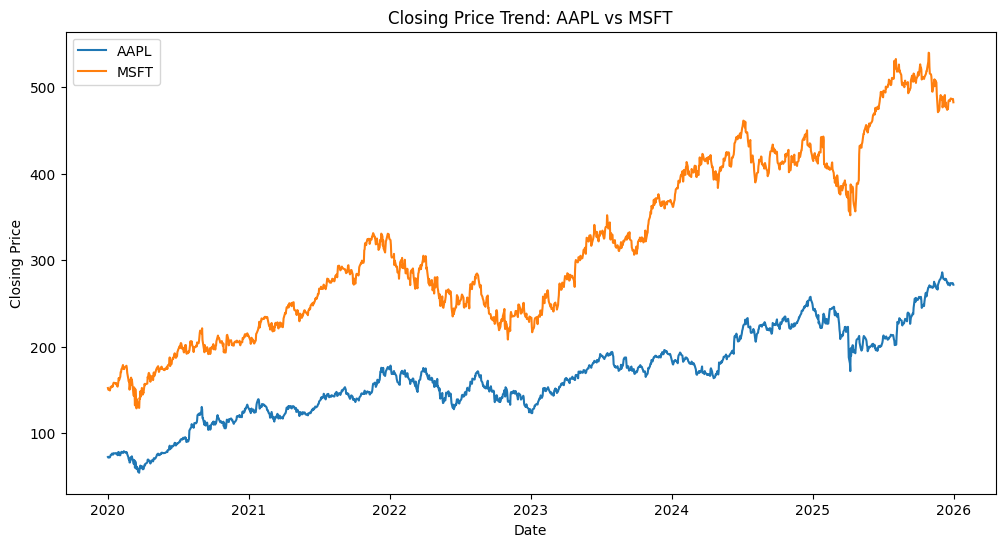

In [127]:
plt.figure(figsize=(12,6))

plt.plot(aapl.index, aapl['Close'], label='AAPL')
plt.plot(msft.index, msft['Close'], label='MSFT')

plt.title("Closing Price Trend: AAPL vs MSFT")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.show()

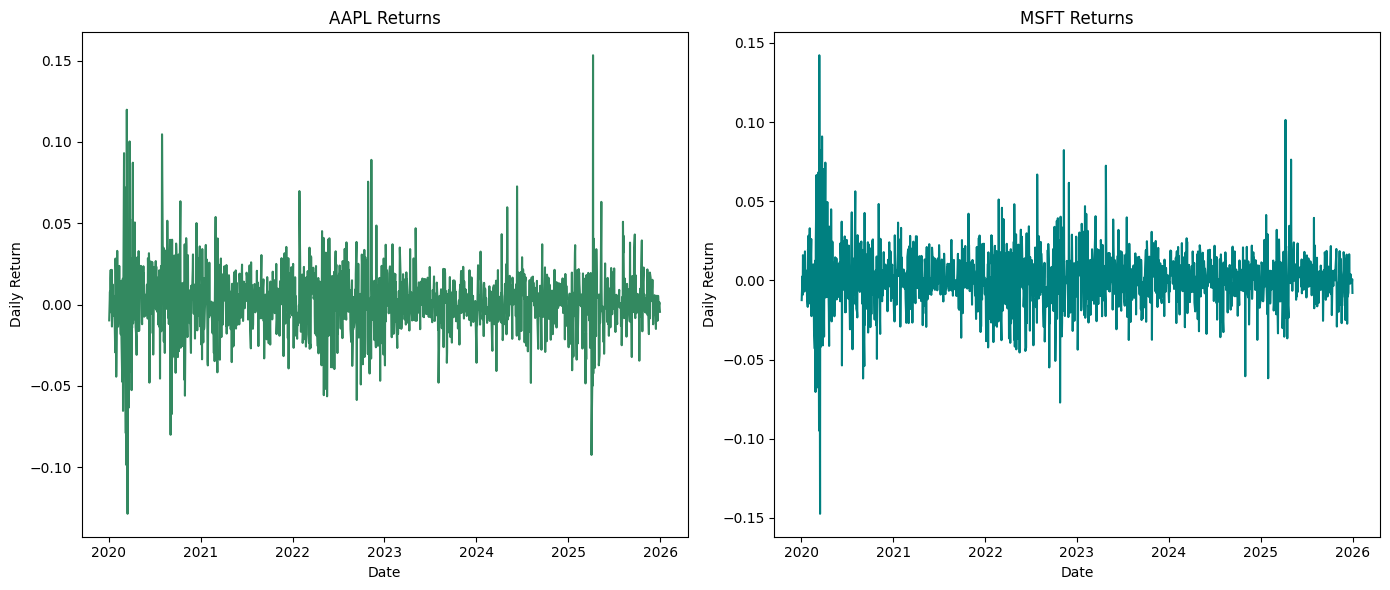

In [128]:
aapl['Return'] = aapl['Close'].pct_change()
msft['Return'] = msft['Close'].pct_change()


fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].plot(aapl.index, aapl['Return'], color='#338960')
axes[0].set_title("AAPL Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Daily Return")

axes[1].plot(msft.index, msft['Return'], color='teal')
axes[1].set_title("MSFT Returns")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily Return")

plt.tight_layout()
plt.show()

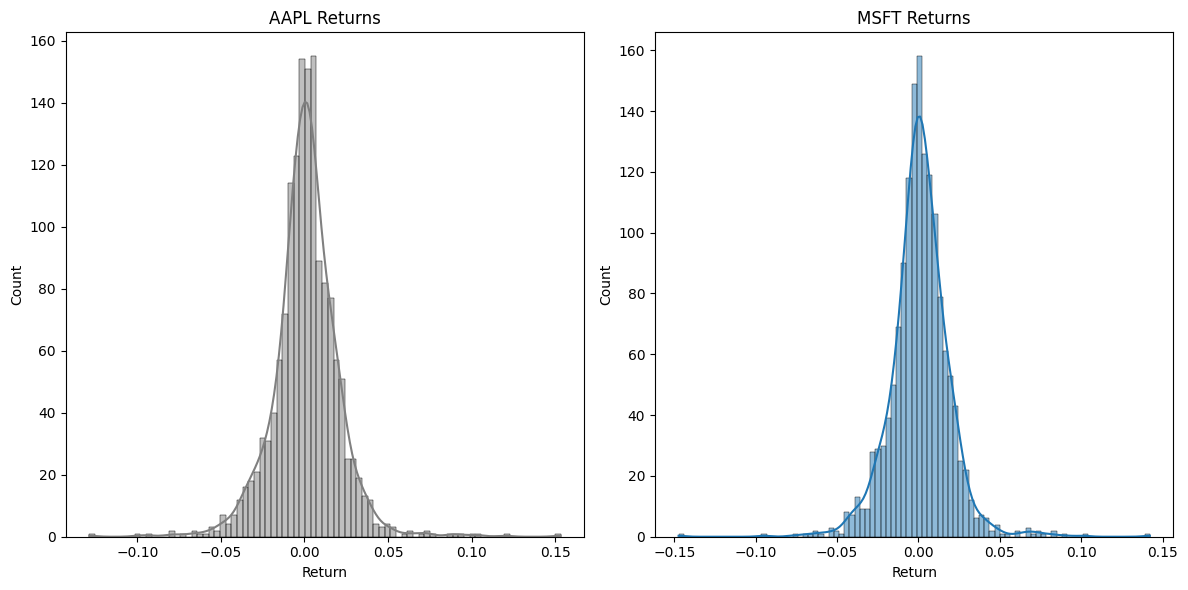

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

sns.histplot(aapl['Return'], kde=True,color="grey", ax=axes[0])
axes[0].set_title("AAPL Returns")

sns.histplot(msft['Return'], kde=True, ax=axes[1])
axes[1].set_title("MSFT Returns")

plt.tight_layout()
plt.show()

In [132]:
print("AAPL Returns Summary:\n",
aapl['Return'].describe())

print("MSFT Returns Summary:\n",
msft['Return'].describe())

AAPL Returns Summary:
 count    1507.000000
mean        0.001078
std         0.020038
min        -0.128647
25%        -0.008210
50%         0.001140
75%         0.011464
max         0.153288
Name: Return, dtype: float64
MSFT Returns Summary:
 count    1507.000000
mean        0.000939
std         0.018613
min        -0.147390
25%        -0.007910
50%         0.001109
75%         0.010426
max         0.142168
Name: Return, dtype: float64


In [137]:
combined = pd.DataFrame({'AAPL': aapl['Return'], 'MSFT': msft['Return']})
print("Correlation:\n", combined.corr())


Correlation:
          AAPL     MSFT
AAPL  1.00000  0.70915
MSFT  0.70915  1.00000


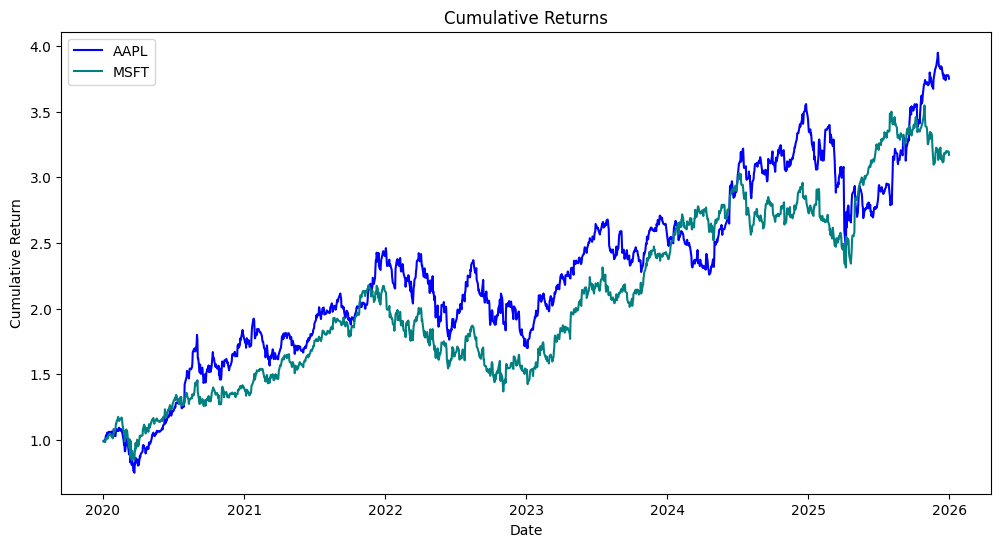

In [135]:
aapl['Cumulative'] = (1 + aapl['Return']).cumprod()
msft['Cumulative'] = (1 + msft['Return']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(aapl['Cumulative'], label='AAPL', color='blue')
plt.plot(msft['Cumulative'], label='MSFT', color='teal')
plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()